In [1]:
with open("input.txt","r") as file:
    text = file.read()



In [2]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

#Code for creating the encoder and decoder
stoi = {ch:i for i ,ch in enumerate(chars)}
itos = {i:ch for i ,ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

print(encode("test"))

[58, 43, 57, 58]


In [3]:
import torch
data = torch.tensor(encode(text),dtype=torch.long)
print(data.shape)

#Split into validation and train set
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

torch.Size([1115393])


In [4]:
torch.manual_seed(1337)

batch_size = 4
block_size = 8

def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data)-block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x,y

# Bigram model


In [ ]:


import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size,vocab_size)

    def forward(self,idx,targets=None):

        logits = self.token_embedding_table(idx)

        if targets == None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T,C)

            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)

        
        return logits, loss
    
    def generate(self,idx,max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)
            logits = logits[:,-1,:]
            probs = F.softmax(logits,dim=-1)
            idx_next = torch.multinomial(probs,num_samples=1)

            idx = torch.cat((idx,idx_next),dim=1)
        return idx
    
m = BigramLanguageModel(vocab_size)
xb,yb = get_batch("train")
out,loss = m(xb,yb)
print(out.shape)
print(loss)



idx = torch.zeros((1,1),dtype=torch.long)
print(decode(m.generate(idx,max_new_tokens=100)[0].tolist()))


torch.Size([32, 65])
tensor(4.7843, grad_fn=<NllLossBackward0>)

P-QWktXoL&jLDJgOLVz'RIoDqHdhsV&vLLxatjscMpwLERSPyao.qfzs$Ys$zF-w,;eEkzxjgCKFChs!iWW.ObzDnxA Ms$3!dcb


2.4713728427886963


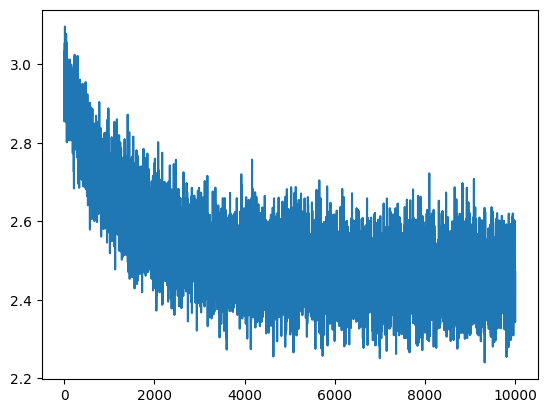

In [17]:
#Bigram optimizer
import matplotlib.pyplot as plt
optimizer = torch.optim.AdamW(m.parameters(),lr=1e-3)

losses = list()

batch_size = 32
steps = 10000
for steps in range(steps):

    xb,yb = get_batch("train")

    logits,loss = m(xb,yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    


    losses.append(loss.item())

print(loss.item())
plt.plot(range(steps+1),losses)
plt.show()

In [19]:
print(decode(m.generate(idx,max_new_tokens=500)[0].tolist()))


ck hisind n towalds thercheng:vefo?
ther PUEY o n!
T:
Rifat thivet ts;
LUS:
Vo pul: owhasay hag is doy. at n thesis as othet y, ng IN h d,

Rakn,
Thim, w tharithamast, vemachin h

DYos male.beede sinarereto te athousiowhenosh oncho wenof sinelenve are, in f MPUS:
BE plemetw sotes:
Frlootht cared y lline adetherer olaishesl:
Sine; f ve be kicank inee.
H:

PEvext



The yoomy wo win, V:
HARNooutheenvysilldingre:
Be OMy henarongas y styoarelind. s her orny t,
TE:

NG lds bengl e tus jutemepeleas th


### The mathematical trick in self-attention

In [21]:
torch.manual_seed(1337)

B,T,C = 4,8,2
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [30]:
#Inefficent attention example
torch.manual_seed(1337)

xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1]
        xbow[b,t] = torch.mean(xprev,0)

print(xbow)

tensor([[[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]],

        [[ 1.3488, -0.1396],
         [ 0.8173,  0.4127],
         [-0.1342,  0.4395],
         [ 0.2711,  0.4774],
         [ 0.2421,  0.0694],
         [ 0.0084,  0.0020],
         [ 0.0712, -0.1128],
         [ 0.2527,  0.2149]],

        [[-0.6631, -0.2513],
         [ 0.1735, -0.0649],
         [ 0.1685,  0.3348],
         [-0.1621,  0.1765],
         [-0.2312, -0.0436],
         [-0.1015, -0.2855],
         [-0.2593, -0.1630],
         [-0.3015, -0.2293]],

        [[ 1.6455, -0.8030],
         [ 1.4985, -0.5395],
         [ 0.4954,  0.3420],
         [ 1.0623, -0.1802],
         [ 1.1401, -0.4462],
         [ 1.0870, -0.4071],
         [ 1.0430, -0.1299],
         [ 1.1138, -0.1641]]])


In [36]:
#Efficient attention
wei = torch.tril(torch.ones(T,T))
wei = wei / wei.sum(1,keepdim=True)

xbow2 = wei @ x

print(torch.allclose(xbow,xbow2))

print(torch.max(xbow-xbow2))


False
tensor(3.2363e-08)


In [39]:
#Version 3 using softmax
tril = torch.tril(torch.ones(T,T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0,float("-inf"))
wei = F.softmax(wei,dim=1)
xbow3 = wei @ x


print(torch.allclose(xbow3,xbow2))
print(torch.max(xbow-xbow3))

True
tensor(3.2363e-08)
